<a href="https://colab.research.google.com/github/Dayaanaly/BioKnee/blob/main/U_net_bioknee_am_dapb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segmentación automatica de rodilla con U-Net**
Dayana Anañy Pacheco Bañuelos

In [ ]:
!pip install pynrrd

Montar el drive

In [ ]:
from google.colab import drive
import os

# Si Drive ya está montado, no lo vuelvas a montar
if os.path.exists('/content/drive/MyDrive'):
    print("Google Drive ya está montado.")
else:
    drive.mount('/content/drive')

Google Drive ya está montado.


In [ ]:
rutas_posibles = [
    '/content/drive',
    '/content/drive/MyDrive',
    '/content/gdrive',
    '/content/gdrive/MyDrive'
]

for ruta in rutas_posibles:
    print("\nRuta:", ruta)
    print("Existe:", os.path.exists(ruta))

    if os.path.exists(ruta):
        try:
            print("Contenido:", os.listdir(ruta)[:10])
        except Exception as e:
            print("No se pudo listar:", e)


Ruta: /content/drive
Existe: True
Contenido: ['MyDrive']

Ruta: /content/drive/MyDrive
Existe: True
Contenido: ['Equipo Trifuerza']

Ruta: /content/gdrive
Existe: False

Ruta: /content/gdrive/MyDrive
Existe: False


Librerías y preprocesamiento

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.model_selection import train_test_split
from google.colab import drive
import cv2  # Para redimensionar imágenes .nrrd
import nrrd  # Para cargar archivos .nrrd

# Parámetros y directorios para rótula
# ------------------------------------

# Directorios de imágenes y máscaras
image_dir = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D'
mask_dir  = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Mascaras mezcladas'

# Parámetros de la imagen y segmentación
# --------------------------------------
IMG_HEIGHT = 320
IMG_WIDTH = 224
IMG_CHANNELS = 1      # Imágenes en escala de grises
NUM_CLASSES = 4       # clases: Rótula, tibia, fémur, fondo
batch_size = 8

# Parámetros ajustables del entrenamiento
# ---------------------------------------
# Estos valores se pueden tunear según el nuevo proyecto o dataset

LEARNING_RATE = 5e-4      # Antes: 0.001. Más estable para segmentación médica
EPOCHS = 60               # Antes: 45. EarlyStopping detiene si ya no mejora
PATIENCE = 8              # Antes: 5. Da más margen antes de detener
DROPOUT_LOW = 0.10        # Regularización ligera en capas iniciales
DROPOUT_MID = 0.20        # Regularización media en capas intermedias
DROPOUT_DEEP = 0.30       # Regularización mayor en la parte profunda
SMOOTH = 1e-6             # Evita divisiones entre cero en Dice e IoU

# Filtrar archivos válidos (.nrrd y .bmp)
valid_extensions = ('.nrrd', '.bmp')
image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)])
mask_files  = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(valid_extensions)])
assert len(image_files) == len(mask_files), "La cantidad de imágenes y máscaras debe ser la misma"

# Función personalizada para cargar imágenes
def load_image_custom(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale'):
    ext = os.path.splitext(filepath)[1].lower()
    if ext == '.nrrd':
        # Cargar usando la librería nrrd
        img_data, header = nrrd.read(filepath)
        # Dependiendo del color_mode, procesamos la imagen:
        if color_mode == 'grayscale':
            # Si la imagen es a color, convertirla a escala de grises (promediando canales)
            if img_data.ndim == 3 and img_data.shape[-1] > 1:
                img_data = np.mean(img_data, axis=-1)
            # Asegurarse de que la imagen sea 2D antes de redimensionar
            # Redimensionar usando cv2 (cv2.resize requiere (ancho, alto))
            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))
            # Agregar la dimensión del canal
            img_resized = np.expand_dims(img_resized, axis=-1)
            return img_resized
        elif color_mode == 'rgb':
            # Si es color, se espera que la imagen tenga 3 canales
            # En caso de tener una sola banda, se replicará
            if img_data.ndim == 2:
                img_data = np.stack((img_data,)*3, axis=-1)
            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))
            return img_resized
        else:
            raise ValueError("Modo de color no soportado: " + color_mode)
    else:
        # Para otros formatos (.bmp), usamos load_img de Keras
        return img_to_array(load_img(filepath, target_size=target_size, color_mode=color_mode))


# Cargar y preprocesar imágenes y máscaras
# ----------------------------------------
images = []
masks = []

for img_file, msk_file in zip(image_files, mask_files):
    image_path = os.path.join(image_dir, img_file)
    mask_path  = os.path.join(mask_dir, msk_file)

    # Cargar la imagen y normalizar (valores entre 0 y 1)
    img = load_image_custom(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale')
    img = img.astype('float32') / 255.0

    # Cargar la máscara (se espera que contenga índices de clase)
    mask = load_image_custom(mask_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale')
    mask = mask.astype(np.int64)
    #Rotar la máscara 90 grados a la izquierda
    mask = np.rot90(mask, k=3, axes=(0, 1))  # 90° horario
    # Redimensiona la máscara para que tenga nuevamente el tamaño
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST) # → (H, W, 1)
    # VOLTEO HORIZONTAL para corregir el “espejo”
    mask = np.fliplr(mask)
    # Aseguramos (H, W, 1)
    # mask = np.expand_dims(mask, axis=-1) comentada por problema de dimensiones
    # Agragar la dimensión del canal para que la máscara tenga forma(alto,ancho,1)
    mask = np.expand_dims(mask, axis=-1)
    images.append(img)
    masks.append(mask)

# Convertir listas a arrays de NumPy
# -----------------------------------

# Verificación y corrección de dimensiones
# images → (N, 320, 224, 1)
# masks  → (N, 320, 224, 1)
if masks.ndim == 5:
    masks = np.squeeze(masks, axis=-1)

print("Forma de images:", images.shape)
print("Forma de masks:", masks.shape)
print("Valores únicos en masks:", np.unique(masks))

# Dividir en conjuntos de entrenamiento y validación
# --------------------------------------------------
# 80% entrenamiento, 20% validación

images_train, images_val, masks_train, masks_val = train_test_split(images,
    masks,test_size=0.20,random_state=42,shuffle=True)

print("Imágenes entrenamiento:", images_train.shape)
print("Máscaras entrenamiento:", masks_train.shape)
print("Imágenes validación:", images_val.shape)
print("Máscaras validación:", masks_val.shape)

# Crear generadores de datos con aumento (augmentation)
# ----------------------------------------------------
data_gen_args = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generadores
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

seed = 42

# Ajuste no estrictamente necesario, pero útil si algún escalador lo requiere
image_datagen.fit(images_train, augment=True, seed=seed)
mask_datagen.fit(masks_train,  augment=True, seed=seed)

train_img_gen = image_datagen.flow(images_train,
                                   batch_size=batch_size,
                                   seed=seed)
train_mask_gen = mask_datagen.flow(masks_train,
                                   batch_size=batch_size,
                                   seed=seed)

def train_generator(): # Las máscaras representan clases enteras: 0 = fondo, 1 = fémur, 2 = tibia, 3 = rótula
    while True:        # Después del aumento de datos pueden aparecer valores decimales, por eso redondeamos y limitamos los valores al rango
        imgs = next(train_img_gen)
        msks = next(train_mask_gen)
        msks = np.rint(msks).astype(np.int32)
        msks = np.clip(msks, 0, NUM_CLASSES - 1)

        yield imgs, msks

# Visualizar algunas imágenes y máscaras aumentadas
# -------------------------------------------------
batch = next(train_generator())
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(batch[0][i].squeeze(), cmap='gray')
    plt.title("Imagen Aumentada")
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(batch[1][i].squeeze(), cmap='gray')
    plt.title("Máscara Aumentada")
    plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D'

Definición U-Net multiclase


*   Métricas+ modelo



In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Métricas de segmentación
# ------------------------
# A diferencia de accuracy, Dice e IoU evalúan qué tan bien coinciden
# las regiones segmentadas con las máscaras reales.

def preparar_y_true(y_true):
   # Convierte la máscara real a formato entero y elimina el canal extra si existe
    y_true = tf.cast(y_true, tf.int32)

    # Si la máscara tiene canal final, lo quitamos
    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    return y_true

def mean_dice(y_true, y_pred):
    #Dice promedio para segmentación multiclase.
    #Dice mide el solapamiento entre la máscara real y la predicha.
    #Un valor cercano a 1 significa mejor segmentación.
    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot:
    # Ejemplo: clase 2 -> [0, 0, 1, 0]
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    # y_pred ya viene como probabilidades por softmax
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    # Calculamos Dice por clase
    axes = [0, 1, 2]
    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes)

    dice = (2.0 * intersection + SMOOTH) / (denominator + SMOOTH)

    # Ignoramos la clase 0 si representa fondo
    # Promediamos solo clases anatómicas: 1, 2 y 3
    dice_foreground = dice[1:]

    return tf.reduce_mean(dice_foreground)


def mean_iou(y_true, y_pred):

    #IoU promedio para segmentación multiclase.
    #IoU mide la intersección sobre la unión entre la máscara real y la predicha.
    #Un valor cercano a 1 indica mejor segmentación.
    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    axes = [0, 1, 2]
    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes) - intersection

    iou = (intersection + SMOOTH) / (union + SMOOTH)

    # Ignoramos fondo y promediamos fémur, tibia y rótula
    iou_foreground = iou[1:]

    return tf.reduce_mean(iou_foreground)


def sparse_ce_dice_loss(y_true, y_pred):

    #Función de pérdida combinada:
    #Sparse Categorical Crossentropy + Dice Loss.

    #Sparse Categorical Crossentropy:
    #- Ayuda a clasificar correctamente cada pixel.

    #Dice Loss:
    #- Ayuda a mejorar el solapamiento de las regiones segmentadas.
    #- Es útil cuando hay mucho fondo y las estructuras son pequeñas.
    y_true_prepared = preparar_y_true(y_true)

    # Pérdida clásica para segmentación multiclase con etiquetas enteras
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true_prepared, y_pred)
    ce = tf.reduce_mean(ce)

    # Dice Loss = 1 - Dice
    dice_loss = 1.0 - mean_dice(y_true, y_pred)

    # Combinamos ambas pérdidas
    total_loss = ce + dice_loss

    return total_loss

# Bloque de convolución
# ---------------------
# Este bloque reemplaza las dos Conv2D repetidas en cada nivel.
# Mantiene la estructura original, pero agrega:
# - BatchNormalization para estabilizar el entrenamiento
# - SpatialDropout2D para reducir sobreajuste

def conv_block(x, filters, dropout_rate=0.0, block_name=""):
    #Bloque básico de la U-Net:
    #Conv2D -> BatchNormalization -> ReLU
    #Conv2D -> BatchNormalization -> ReLU
    #SpatialDropout2D opcional

    # Primera convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv1'
    )(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)

    # Segunda convolución
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv2'
    )(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)

    # Dropout espacial: apaga mapas de características completos
    # Es más adecuado para CNN que Dropout normal
    if dropout_rate > 0:
        x = layers.SpatialDropout2D(
            dropout_rate,
            name=f'{block_name}_spatial_dropout'
        )(x)

    return x

# Definir la U-Net para segmentación multi-clase
# ----------------------------------------------
def U_net(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(shape=input_shape)


    # Encoder / Camino descendente
    # ----------------------------
    # Aquí la red reduce la resolución y aprende características:
    # bordes, texturas, contornos y patrones anatómicos.

    # Bloque Down 1
    conv1 = conv_block(inputs, 64, dropout_rate=DROPOUT_LOW, block_name="down1")
    pool1 = layers.MaxPooling2D((2, 2), name="pool1")(conv1)

    # Bloque Down 2
    conv2 = conv_block(pool1, 128, dropout_rate=DROPOUT_LOW, block_name="down2")
    pool2 = layers.MaxPooling2D((2, 2), name="pool2")(conv2)

    # Bloque Down 3
    conv3 = conv_block(pool2, 256, dropout_rate=DROPOUT_MID, block_name="down3")
    pool3 = layers.MaxPooling2D((2, 2), name="pool3")(conv3)


    # Bloque intermedio / Bottleneck
    # ------------------------------
    # Es la parte más profunda de la red.
    # Aquí aprende características más abstractas de la rodilla.
    conv4 = conv_block(pool3, 512, dropout_rate=DROPOUT_DEEP, block_name="bottleneck")

    # Decoder / Camino ascendente
    # ---------------------------
    # Aquí la red recupera resolución para construir la máscara final.
    # Las concatenaciones conservan detalles finos del encoder.

    # Up 1
    up1 = layers.UpSampling2D((2, 2), name="up1_sampling")(conv4)
    up1 = layers.Conv2D(
        256,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="up1_conv"
    )(up1)

    # Conexión tipo puente con conv3
    concat1 = layers.concatenate([up1, conv3], name="concat1")
    conv5 = conv_block(concat1, 256, dropout_rate=DROPOUT_MID, block_name="up1")

    # Up 2
    up2 = layers.UpSampling2D((2, 2), name="up2_sampling")(conv5)
    up2 = layers.Conv2D(
        128,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="up2_conv"
    )(up2)

    # Conexión tipo puente con conv2
    concat2 = layers.concatenate([up2, conv2], name="concat2")
    conv6 = conv_block(concat2, 128, dropout_rate=DROPOUT_LOW, block_name="up2")

    # Up 3
    up3 = layers.UpSampling2D((2, 2), name="up3_sampling")(conv6)
    up3 = layers.Conv2D(
        64,
        2,
        padding='same',
        kernel_initializer='he_normal',
        activation='relu',
        name="up3_conv"
    )(up3)

    # Conexión tipo puente con conv1
    concat3 = layers.concatenate([up3, conv1], name="concat3")
    conv7 = conv_block(concat3, 64, dropout_rate=0.0, block_name="up3")

    # Capa de salida
    # --------------
    # NUM_CLASSES canales con softmax.
    # Para cada pixel, la red calcula la probabilidad de pertenecer a cada clase:
    # 0 = fondo
    # 1 = fémur
    # 2 = tibia
    # 3 = rótula
    outputs = layers.Conv2D(
        num_classes,
        1,
        activation='softmax',
        name="segmentation_output"
    )(conv7)

    model = models.Model(inputs, outputs, name="U_Net_Rodilla_Multiclase")

    return model

# Crear y compilar el modelo
# --------------------------
model = U_net()

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=sparse_ce_dice_loss,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='pixel_accuracy'),
        mean_dice,
        mean_iou
    ]
)

# Mostrar resumen de la arquitectura
model.summary()

Model: "U_Net_Rodilla_Multiclase"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_conv1         │ (None, 320, 224,  │        640 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_bn1           │ (None, 320, 224,  │        256 │ down1_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_relu1         │ (None, 320, 224,  │          0 │ down1_bn1[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_conv2         │ (None, 320, 224,  │     36,928 │ down1_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_bn2           │ (None, 320, 224,  │        256 │ down1_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_relu2         │ (None, 320, 224,  │          0 │ down1_bn2[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down1_spatial_drop… │ (None, 320, 224,  │          0 │ down1_relu2[0][0] │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 160, 112,  │          0 │ down1_spatial_dr… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_conv1         │ (None, 160, 112,  │     73,856 │ pool1[0][0]       │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_bn1           │ (None, 160, 112,  │        512 │ down2_conv1[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_relu1         │ (None, 160, 112,  │          0 │ down2_bn1[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_conv2         │ (None, 160, 112,  │    147,584 │ down2_relu1[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_bn2           │ (None, 160, 112,  │        512 │ down2_conv2[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_relu2         │ (None, 160, 112,  │          0 │ down2_bn2[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down2_spatial_drop… │ (None, 160, 112,  │          0 │ down2_relu2[0][0] │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 80, 56,    │          0 │ down2_spatial_dr

 Total params: 7,707,652 (29.40 MB)

 Trainable params: 7,702,020 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

Entrenamiento

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.8883 - mean_dice: 0.1600 - mean_iou: 0.0898 - pixel_accuracy: 0.6088   
Epoch 1: val_mean_dice improved from None to 0.14949, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - loss: 1.7501 - mean_dice: 0.1924 - mean_iou: 0.1104 - pixel_accuracy: 0.6585 - val_loss: 6.8423 - val_mean_dice: 0.1495 - val_mean_iou: 0.0837 - val_pixel_accuracy: 0.1319 - learning_rate: 5.0000e-04
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - loss: 1.5008 - mean_dice: 0.2744 - mean_iou: 0.1662 - pixel_accuracy: 0.7259
Epoch 2: val_mean_dice improved from 0.14949 to 0.19595, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 555ms/step - loss: 1.4495 - mean_dice: 0.2913 - mean_iou: 0.1782 - pixel_accuracy: 0.7328 - val_loss: 5.8410 - val_mean_dice: 0.1959 - val_mean_iou: 0.1121 - val_pixel_accuracy: 0.2478 - learning_rate: 5.0000e-04
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - loss: 1.2705 - mean_dice: 0.3644 - mean_iou: 0.2315 - pixel_accuracy: 0.7666
Epoch 3: val_mean_dice did not improve from 0.19595
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 532ms/step - loss: 1.2173 - mean_dice: 0.3952 - mean_iou: 0.2555 - pixel_accuracy: 0.7818 - val_loss: 3.8026 - val_mean_dice: 0.1857 - val_mean_iou: 0.1072 - val_pixel_accuracy: 0.4885 - learning_rate: 5.0000e-04
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - loss: 1.0816 - mean_dice: 0.4799 - mean_iou: 0.3246 - pixel_accuracy: 0.8087
Epoch 4: val_mean_dice did not improve from 0.19595
22/22 ━━━━━━━


Epoch 10: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 600ms/step - loss: 0.6595 - mean_dice: 0.7020 - mean_iou: 0.5451 - pixel_accuracy: 0.8862 - val_loss: 1.9891 - val_mean_dice: 0.2501 - val_mean_iou: 0.1531 - val_pixel_accuracy: 0.7339 - learning_rate: 5.0000e-04
Epoch 11/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 0.6093 - mean_dice: 0.7202 - mean_iou: 0.5671 - pixel_accuracy: 0.8965
Epoch 11: val_mean_dice improved from 0.25013 to 0.33697, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5



Epoch 11: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 542ms/step - loss: 0.6245 - mean_dice: 0.7179 - mean_iou: 0.5653 - pixel_accuracy: 0.8933 - val_loss: 1.8743 - val_mean_dice: 0.3370 - val_mean_iou: 0.2053 - val_pixel_accuracy: 0.7085 - learning_rate: 5.0000e-04
Epoch 12/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 0.5906 - mean_dice: 0.7312 - mean_iou: 0.5804 - pixel_accuracy: 0.8988
Epoch 12: val_mean_dice improved from 0.33697 to 0.36036, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5


...


Epoch 44: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 599ms/step - loss: 0.3282 - mean_dice: 0.8516 - mean_iou: 0.7440 - pixel_accuracy: 0.9460 - val_loss: 0.3805 - val_mean_dice: 0.8480 - val_mean_iou: 0.7370 - val_pixel_accuracy: 0.9346 - learning_rate: 6.2500e-05
Epoch 45/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - loss: 0.4141 - mean_dice: 0.8253 - mean_iou: 0.7078 - pixel_accuracy: 0.9308
Epoch 45: val_mean_dice did not improve from 0.84805
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - loss: 0.3750 - mean_dice: 0.8390 - mean_iou: 0.7266 - pixel_accuracy: 0.9372 - val_loss: 0.3823 - val_mean_dice: 0.8473 - val_mean_iou: 0.7360 - val_pixel_accuracy: 0.9344 - learning_rate: 6.2500e-05
Epoch 46/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 0.3932 - mean_dice: 0.8358 - mean_iou: 0.7211 - pixel_accuracy: 0.9346
Epoch 46: val_mean_dice did not improve from 0.84805

Epoch 4


Epoch 51: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - loss: 0.3394 - mean_dice: 0.8525 - mean_iou: 0.7453 - pixel_accuracy: 0.9427 - val_loss: 0.3824 - val_mean_dice: 0.8484 - val_mean_iou: 0.7374 - val_pixel_accuracy: 0.9337 - learning_rate: 1.5625e-05
Epoch 52/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - loss: 0.3655 - mean_dice: 0.8426 - mean_iou: 0.7316 - pixel_accuracy: 0.9403
Epoch 52: val_mean_dice did not improve from 0.84841

Epoch 52: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - loss: 0.3604 - mean_dice: 0.8453 - mean_iou: 0.7354 - pixel_accuracy: 0.9405 - val_loss: 0.3833 - val_mean_dice: 0.8483 - val_mean_iou: 0.7372 - val_pixel_accuracy: 0.9334 - learning_rate: 1.5625e-05
Epoch 53/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - loss: 0.3262 - mean_dice: 0.8559 - mean_iou: 0.7502 - pixel_


Epoch 53: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 595ms/step - loss: 0.3471 - mean_dice: 0.8491 - mean_iou: 0.7403 - pixel_accuracy: 0.9424 - val_loss: 0.3832 - val_mean_dice: 0.8486 - val_mean_iou: 0.7377 - val_pixel_accuracy: 0.9335 - learning_rate: 7.8125e-06
Epoch 54/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 0.3766 - mean_dice: 0.8409 - mean_iou: 0.7289 - pixel_accuracy: 0.9362
Epoch 54: val_mean_dice did not improve from 0.84856
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 517ms/step - loss: 0.3745 - mean_dice: 0.8408 - mean_iou: 0.7282 - pixel_accuracy: 0.9369 - val_loss: 0.3839 - val_mean_dice: 0.8482 - val_mean_iou: 0.7371 - val_pixel_accuracy: 0.9333 - learning_rate: 7.8125e-06
Epoch 55/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 0.3154 - mean_dice: 0.8597 - mean_iou: 0.7567 - pixel_accuracy: 0.9479
Epoch 55: val_mean_dice did not improve from 0.84856

Epoch 5


Epoch 57: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 597ms/step - loss: 0.3579 - mean_dice: 0.8483 - mean_iou: 0.7393 - pixel_accuracy: 0.9392 - val_loss: 0.3827 - val_mean_dice: 0.8488 - val_mean_iou: 0.7380 - val_pixel_accuracy: 0.9336 - learning_rate: 3.9063e-06
Epoch 58/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 0.3279 - mean_dice: 0.8545 - mean_iou: 0.7476 - pixel_accuracy: 0.9451
Epoch 58: val_mean_dice improved from 0.84877 to 0.84891, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5



Epoch 58: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado.h5

Epoch 58: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 595ms/step - loss: 0.3486 - mean_dice: 0.8495 - mean_iou: 0.7408 - pixel_accuracy: 0.9415 - val_loss: 0.3827 - val_mean_dice: 0.8489 - val_mean_iou: 0.7382 - val_pixel_accuracy: 0.9336 - learning_rate: 3.9063e-06
Epoch 59/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 0.3487 - mean_dice: 0.8458 - mean_iou: 0.7362 - pixel_accuracy: 0.9411
Epoch 59: val_mean_dice did not improve from 0.84891
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - loss: 0.3536 - mean_dice: 0.8452 - mean_iou: 0.7353 - pixel_accuracy: 0.9405 - val_loss: 0.3830 - val_mean_dice: 0.8489 - val_mean_iou: 0.7381 - val_pixel_accuracy: 0.9335 - learning_rate: 1.9531e-06
Epoch 60/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 0.3682 - mean_dice: 0.8424 - mean_iou: 0.7304 - pixel

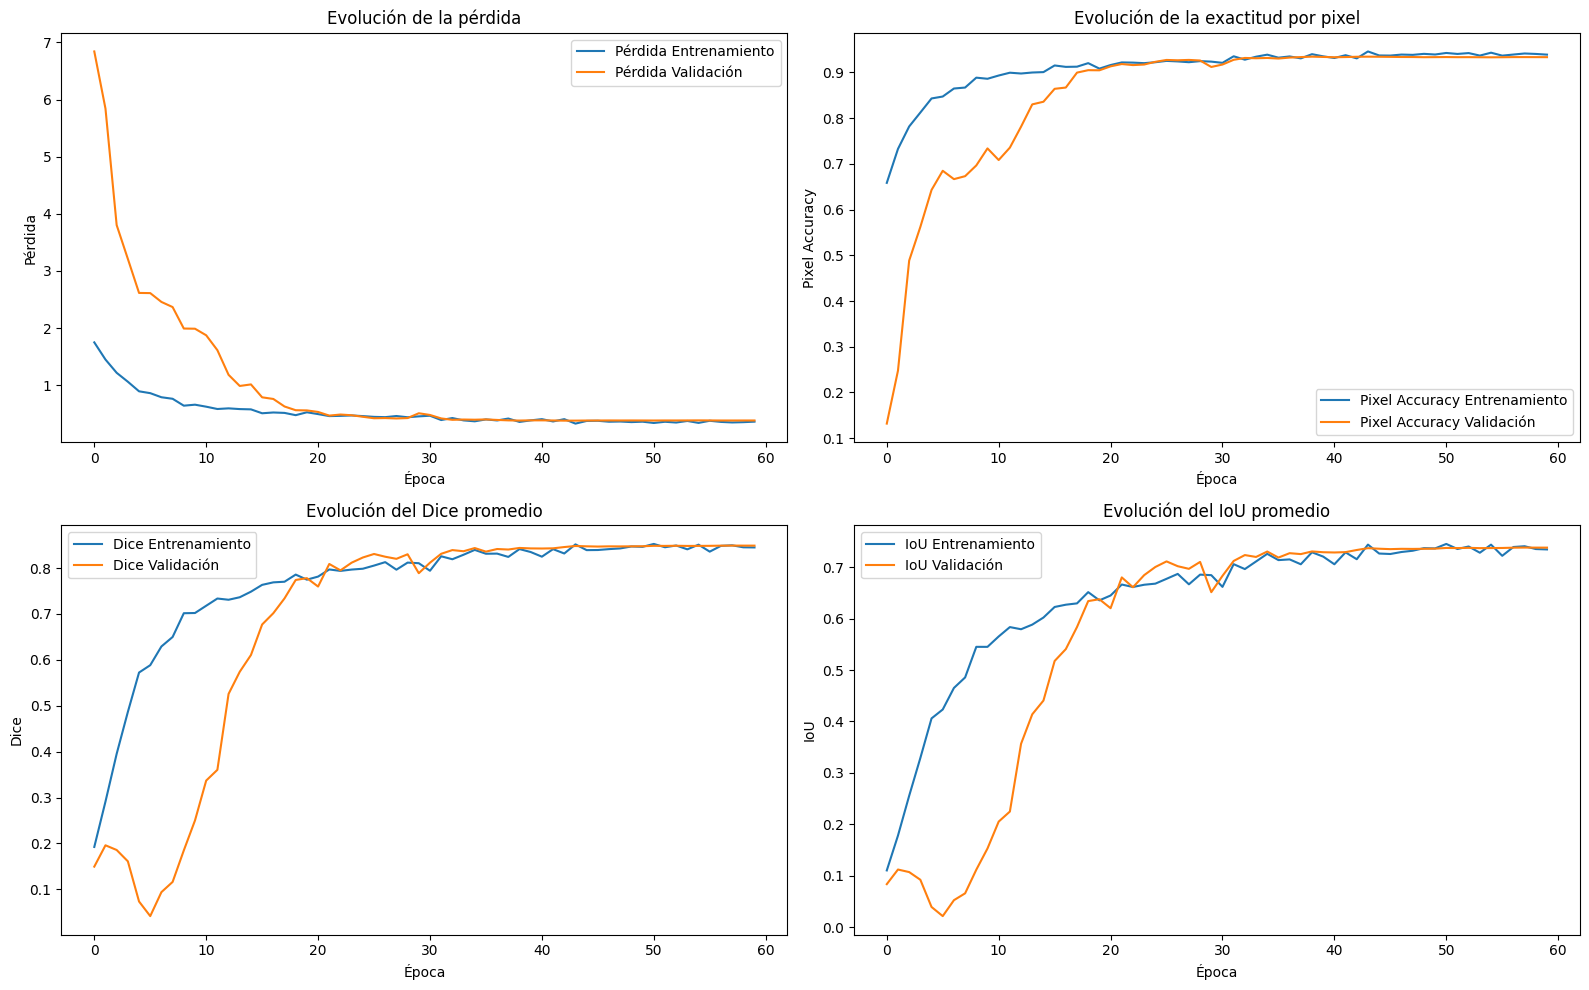

In [ ]:
# Entrenamiento
# -------------
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configuración de pasos de entrenamiento
steps_per_epoch = len(images_train) // batch_size
validation_steps = len(images_val) // batch_size

# Callbacks de entrenamiento
checkpoint_path = '/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Checkpoint/Save_Unet_model_mejorado_1.h5'

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_mean_dice',      # Ahora guardamos según Dice de validación
    save_best_only=True,          # Guarda sólo cuando mejora
    save_weights_only=False,      # Guarda todo el modelo
    mode='max',                   # Dice debe maximizarse
    verbose=1                     # se imprime mensaje guardado
)

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_mean_dice',      # Monitorea Dice de validación
    patience=PATIENCE,            # Espera más épocas antes de detener
    restore_best_weights=True,    # Restaura los mejores pesos
    mode='max',
    verbose=1
)

# ReduceLROnPlateau
# Si el modelo se estanca, reduce el learning rate para afinar el aprendizaje
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # Reduce el learning rate a la mitad
    patience=3,                   # Si no mejora en 3 épocas
    min_lr=1e-6,                  # Límite inferior del learning rate
    verbose=1
)

# Validación SIN augmentación
# Es importante validar con imágenes reales, no aumentadas.
val_data = (images_val, masks_val)

# Entrenamiento del modelo
history = model.fit(
    train_generator(),
    steps_per_epoch = steps_per_epoch,
    epochs           = EPOCHS,
    validation_data  = val_data,
    validation_steps = None,
    callbacks        = [checkpoint_cb, early_stop, reduce_lr]
)

# Guardar el modelo entrenado
# ---------------------------
# Ruta personalizada en Drive
model_path = '/content/drive/MyDrive/Equipo Trifuerza/Códigos fuentes/Modelos entrenados/U-Net_entrenada_60e_mejorada.keras'
model.save(model_path)
print("Modelo guardado en:", model_path)

# Evaluación final en validación
# Esto imprime pérdida, accuracy por pixel, Dice e IoU.
results = model.evaluate(images_val, masks_val, verbose=1)

print("\nResultados en validación:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Graficas de curvas de entrenamiento
# --------------------------------
plt.figure(figsize=(16, 10))

# Pérdida
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Evolución de la pérdida')
plt.legend()

# Exactitud por pixel
plt.subplot(2, 2, 2)
plt.plot(history.history['pixel_accuracy'], label='Pixel Accuracy Entrenamiento')
plt.plot(history.history['val_pixel_accuracy'], label='Pixel Accuracy Validación')
plt.xlabel('Época')
plt.ylabel('Pixel Accuracy')
plt.title('Evolución de la exactitud por pixel')
plt.legend()

# Dice
plt.subplot(2, 2, 3)
plt.plot(history.history['mean_dice'], label='Dice Entrenamiento')
plt.plot(history.history['val_mean_dice'], label='Dice Validación')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('Evolución del Dice promedio')
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(history.history['mean_iou'], label='IoU Entrenamiento')
plt.plot(history.history['val_mean_iou'], label='IoU Validación')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('Evolución del IoU promedio')
plt.legend()

plt.tight_layout()
plt.show()


### Visualización mascaras automáticas

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Shapes → preds_classes: (3, 320, 224)  true_classes: (3, 320, 224)


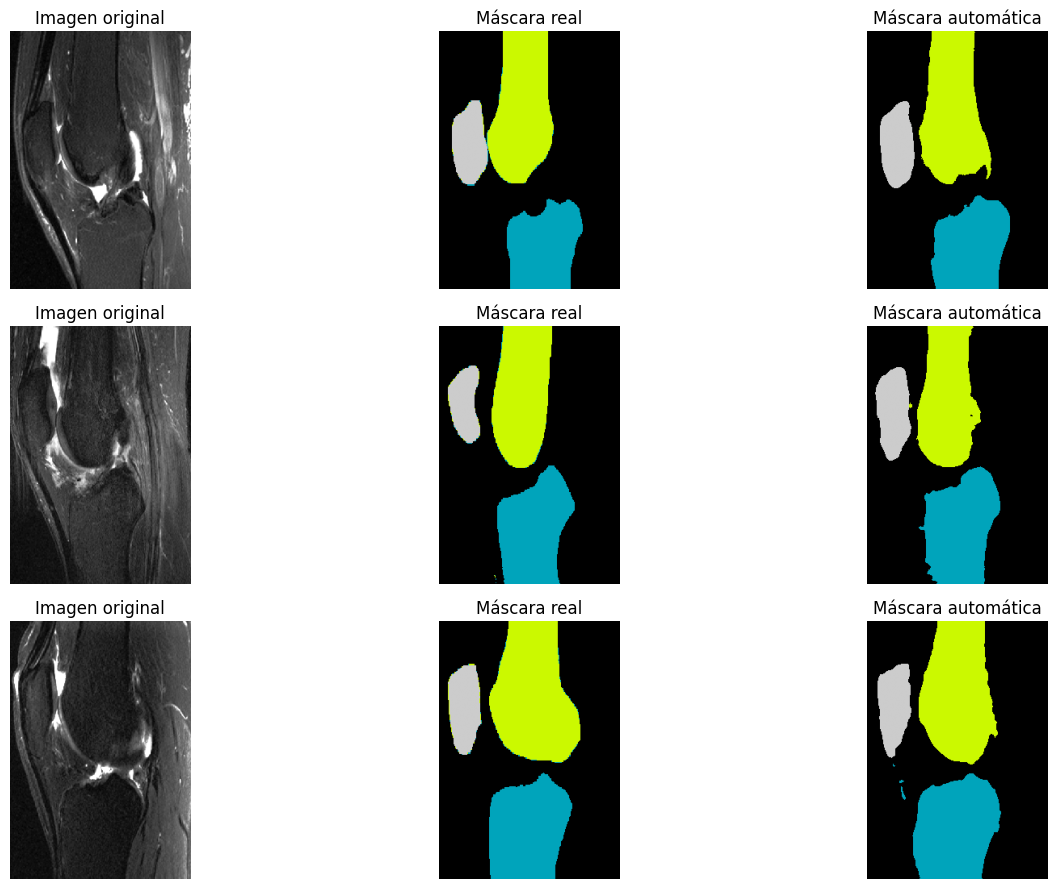

In [ ]:
# Elegir muestras
num_samples   = 3
sample_images = images_val[:num_samples]
sample_masks  = masks_val[:num_samples]

# Predicciones
preds = model.predict(sample_images)
preds_classes = np.argmax(preds, axis=-1)

# Quitar cualquier dimensión extra
true_classes = np.squeeze(sample_masks)

print("Shapes → preds_classes:", preds_classes.shape,
      " true_classes:", true_classes.shape)
#   Deben coincidir en (5, 320, 224)

# Visualización
plt.figure(figsize=(15, num_samples * 3))
for i in range(num_samples):
    # Original
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title('Imagen original'); plt.axis('off')
    # Máscara real
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(true_classes[i], cmap='nipy_spectral',
               vmin=0, vmax=NUM_CLASSES-1)
    plt.title('Máscara real'); plt.axis('off')
    # Máscara predicha
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(preds_classes[i], cmap='nipy_spectral',
               vmin=0, vmax=NUM_CLASSES-1)
    plt.title('Máscara automática'); plt.axis('off')

plt.tight_layout()
plt.show()


Guardar datos de entrenamiento


In [ ]:

# Evaluación final del modelo U-Net mejorada
# ================================

results = model.evaluate(images_val, masks_val, verbose=1)

print("\nResultados finales en validación:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 0.3827 - mean_dice: 0.8489 - mean_iou: 0.7382 - pixel_accuracy: 0.9336

Resultados finales en validación:
loss: 0.3827
compile_metrics: 0.9336


In [ ]:
# ================================
# Guardar historial de entrenamiento
# ================================

import pandas as pd

history_df = pd.DataFrame(history.history)

history_path = '/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/history_unet_mejorada.csv'
history_df.to_csv(history_path, index=False)

print("Historial guardado en:", history_path)

Historial guardado en: /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/history_unet_mejorada.csv


In [ ]:
plt.savefig('/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/graficas_unet_mejorada.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

##Suavizar contorno de la mascara


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. Cargar el modelo
model_path = '/content/drive/MyDrive/Equipo Trifuerza/Códigos fuentes/Modelos entrenados/U-Net_entrenada_60e_mejorada.keras'
model = load_model(model_path)

# 2. Preparar muestras
num_samples   = 3
sample_images = images_val[:num_samples]            # ya normalizadas
sample_masks  = masks_val[:num_samples]
true_classes  = np.squeeze(sample_masks)            # (5, H, W)

# 3. Inferencia
preds = model.predict(sample_images)
preds_classes = np.argmax(preds, axis=-1)           # (5, H, W)

# 4. Post-procesado morfológico
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
preds_eroded = []
for pc in preds_classes:
    eroded_label = np.zeros_like(pc, dtype=np.uint8)
    for lbl in [1, 2, 3]:
        bin_mask = (pc == lbl).astype(np.uint8) * 255
        eroded = cv2.erode(bin_mask, kernel, iterations=2)
        eroded_label[eroded > 0] = lbl
    preds_eroded.append(eroded_label)
preds_eroded = np.stack(preds_eroded, axis=0)

# 5. Visualización
plt.figure(figsize=(15, num_samples * 3))
for i in range(num_samples):
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(true_classes[i], cmap='nipy_spectral',
               vmin=0, vmax=NUM_CLASSES-1)
    plt.axis('off')
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(preds_eroded[i], cmap='nipy_spectral',
               vmin=0, vmax=NUM_CLASSES-1)
    plt.axis('off')
plt.tight_layout()
plt.show()


TypeError: Could not locate function 'sparse_ce_dice_loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'sparse_ce_dice_loss', 'registered_name': 'function'}

Visualización


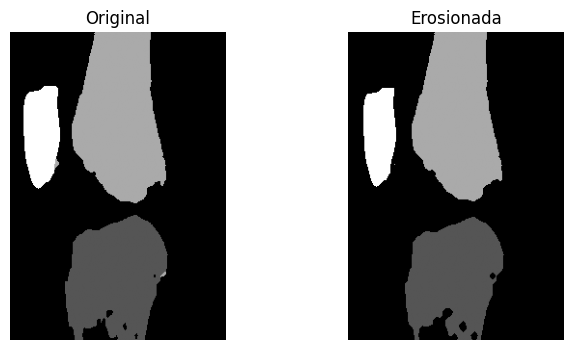

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(pc, cmap='gray');        axs[0].set_title('Original');  axs[0].axis('off')
axs[1].imshow(eroded_label, cmap='gray'); axs[1].set_title('Erosionada'); axs[1].axis('off')
plt.show()